In [6]:

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("hedge_fund.db")

# Verify the existing database tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

display(tables)

,name
0,daily_prices
1,portfolio_holdings
2,portfolio_weights


In [7]:

holdings = pd.DataFrame({
    "ticker": ["AAPL", "BLK", "GS", "JPM", "MSFT"],
    "weight": [0.20, 0.20, 0.20, 0.20, 0.20]
})

# Store holdings in SQLite
holdings.to_sql(
    "portfolio_holdings",
    conn,
    if_exists="replace",
    index=False
)

display(
    pd.read_sql_query(
        "SELECT * FROM portfolio_holdings;",
        conn
    )
)


,ticker,weight
0,AAPL,0.2
1,BLK,0.2
2,GS,0.2
3,JPM,0.2
4,MSFT,0.2


In [8]:

query = """
WITH stock_returns AS (
    SELECT
        date,
        ticker,
        close_price,
        LAG(close_price) OVER (
            PARTITION BY ticker
            ORDER BY date
        ) AS previous_close
    FROM daily_prices
),
weighted_returns AS (
    SELECT
        r.date,
        r.ticker,
        w.weight,
        (r.close_price / r.previous_close - 1) AS daily_return,
        w.weight * (r.close_price / r.previous_close - 1)
            AS weighted_return
    FROM stock_returns r
    INNER JOIN portfolio_weights w
        ON r.ticker = w.ticker
    WHERE r.previous_close IS NOT NULL
)
SELECT
    date,
    ROUND(SUM(weighted_return) * 100, 4)
        AS portfolio_return_pct,
    COUNT(*) AS stocks
FROM weighted_returns
GROUP BY date
HAVING COUNT(*) = 5
ORDER BY date;
"""

portfolio_returns = pd.read_sql_query(query, conn)
display(portfolio_returns.head(10))

,date,portfolio_return_pct,stocks
0,2025-09-24,-0.4982,5
1,2025-09-25,0.6422,5
2,2025-09-26,0.5862,5
3,2025-09-29,0.3894,5
4,2025-09-30,-0.2287,5
5,2025-10-01,-0.8646,5
6,2025-10-02,-0.0395,5
7,2025-10-03,0.5675,5
8,2025-10-06,0.8651,5
9,2025-10-07,-0.6865,5


In [9]:

import pandas as pd
import sqlite3

conn = sqlite3.connect("hedge_fund.db")

# Create the portfolio weights table
weights = pd.DataFrame({
    "ticker": ["AAPL", "BLK", "GS", "JPM", "MSFT"],
    "weight": [0.20, 0.20, 0.20, 0.20, 0.20]
})

weights.to_sql(
    "portfolio_weights",
    conn,
    if_exists="replace",
    index=False
)

# Confirm that the table exists
display(pd.read_sql_query(
    "SELECT * FROM portfolio_weights;",
    conn
))

,ticker,weight
0,AAPL,0.2
1,BLK,0.2
2,GS,0.2
3,JPM,0.2
4,MSFT,0.2


In [10]:

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

display(tables)


,name
0,daily_prices
1,portfolio_holdings
2,portfolio_weights


In [11]:

query = """
WITH stock_returns AS (
    SELECT
        date,
        ticker,
        close_price,
        LAG(close_price) OVER (
            PARTITION BY ticker
            ORDER BY date
        ) AS previous_price
    FROM daily_prices
),
weighted_returns AS (
    SELECT
        s.date,
        s.ticker,
        (s.close_price / s.previous_price - 1) * w.weight
            AS weighted_return
    FROM stock_returns s
    JOIN portfolio_weights w
        ON s.ticker = w.ticker
    WHERE s.previous_price IS NOT NULL
)
SELECT
    date,
    ROUND(SUM(weighted_return) * 100, 4)
        AS portfolio_return_pct
FROM weighted_returns
GROUP BY date
HAVING COUNT(*) = 5
ORDER BY date;
"""

portfolio_returns = pd.read_sql_query(query, conn)

display(portfolio_returns.head(10))
print("Trading days:", len(portfolio_returns))

,date,portfolio_return_pct
0,2025-09-24,-0.4982
1,2025-09-25,0.6422
2,2025-09-26,0.5862
3,2025-09-29,0.3894
4,2025-09-30,-0.2287
5,2025-10-01,-0.8646
6,2025-10-02,-0.0395
7,2025-10-03,0.5675
8,2025-10-06,0.8651
9,2025-10-07,-0.6865


Trading days: 249


In [12]:

portfolio_returns["cumulative_return_pct"] = (
    (1 + portfolio_returns["portfolio_return_pct"] / 100)
    .cumprod() - 1
) * 100

display(portfolio_returns.tail(10))

,date,portfolio_return_pct,cumulative_return_pct
239,2026-09-08,-1.1702,15.236291
240,2026-09-09,-0.6566,14.479649
241,2026-09-10,0.3247,14.851365
242,2026-09-11,1.1390,16.159522
243,2026-09-14,-0.9508,15.055077
244,2026-09-15,-0.6663,14.288465
245,2026-09-16,-1.6093,12.449221
246,2026-09-17,1.2124,13.812555
247,2026-09-18,-0.0894,13.710807
248,2026-09-21,1.3746,15.273875


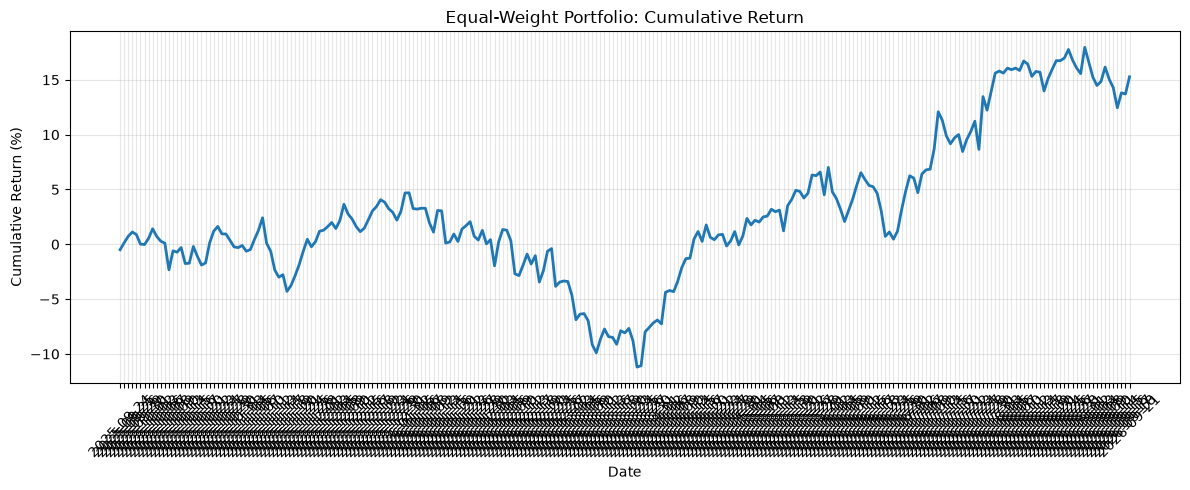

In [13]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    portfolio_returns["date"],
    portfolio_returns["cumulative_return_pct"],
    linewidth=2
)

plt.title("Equal-Weight Portfolio: Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

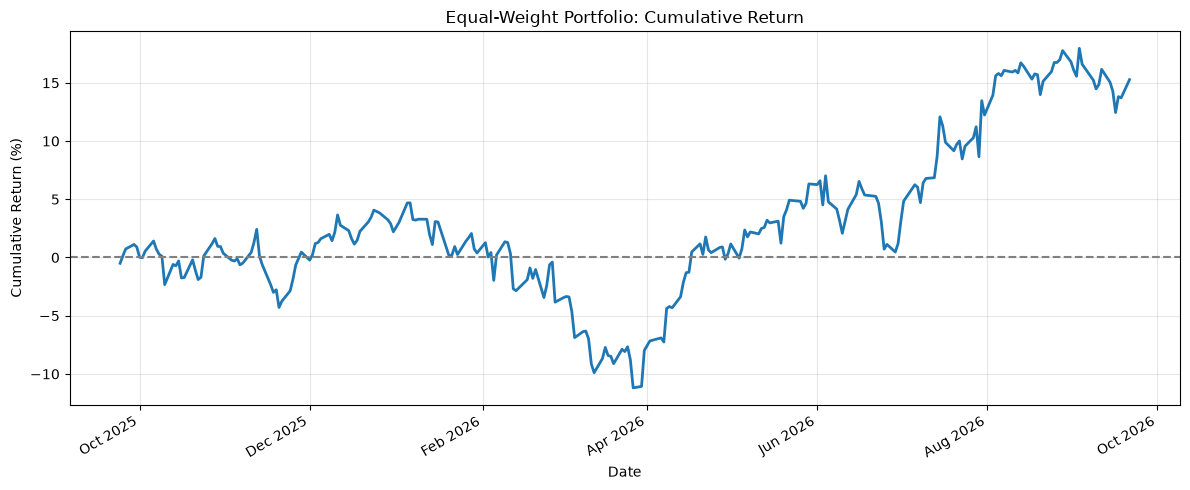

In [14]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

portfolio_returns["date"] = pd.to_datetime(
    portfolio_returns["date"]
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    portfolio_returns["date"],
    portfolio_returns["cumulative_return_pct"],
    linewidth=2
)

ax.axhline(0, color="gray", linestyle="--")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax.set_title("Equal-Weight Portfolio: Cumulative Return")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()